In [1]:
import numba
from numba import cuda, njit, prange, float32, int32, int64
import math
from sklearn.utils import compute_class_weight
import numpy as np
import pandas as pd
import scanpy as sc
import sys
sys.path.append('../simulator/')
from CME_func import CME
from hiererchical_simulator import *
import seaborn as sns
import matplotlib.pyplot as plt
import time

/home/shadeform/anaconda3/envs/FAST_CME/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [ ]:
adata = sc.read_h5ad('../sim_data/adata/adata_16.h5ad')
adata.shape

<Axes: >

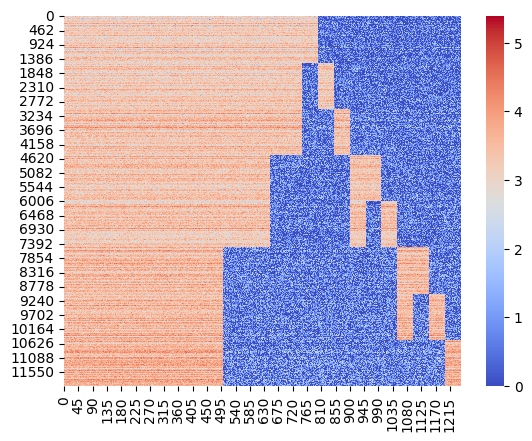

In [26]:
X = adata.X.T.astype(np.float32)
indices = np.array([i for i in range(1000, 1200)])
sns.heatmap(np.log(adata.X+1), cmap='coolwarm')

In [ ]:
start = time.time()
print("Running CUDA version...")
result_cuda = CME(X, normalize=False, feature_indices=None, cuda=True)
print(f"CUDA result shape: {result_cuda.shape}")
end = time.time()
gpu_time = end-start
print(gpu_time)

Running CUDA version...
CUDA result shape: (1250, 1250)


<Axes: >

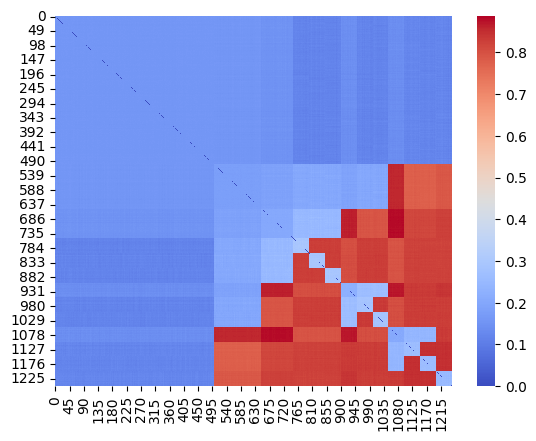

In [44]:
sns.heatmap(result_cuda, cmap='coolwarm')

In [45]:
start = time.time()
# 测试CPU版本（用于验证）
print("Running CPU version for verification...")
result_cpu = CME(X)
print(f"CPU result shape: {result_cpu.shape}")
end = time.time()
cpu_time = end-start

Running CPU version for verification...


CPU result shape: (1250, 1250)


<Axes: >

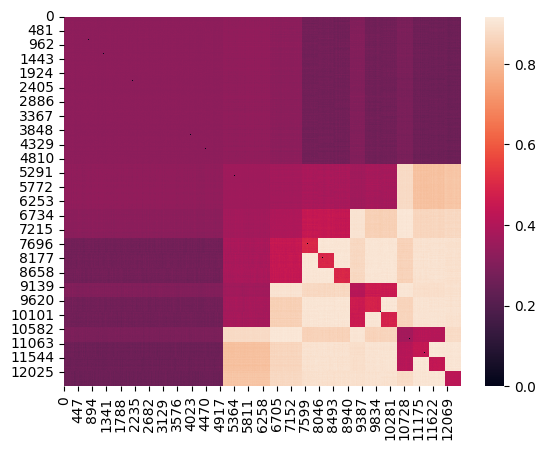

In [ ]:
sns.heatmap(result_cpu, cmap='coolwarm')

In [ ]:
cpu_res = pd.DataFrame(result_cpu)
gpu_res = pd.DataFrame(result_cuda)
cpu_res.to_csv('cpu_results.csv', index=False)  
gpu_res.to_csv('gpu_results.csv', index=False)

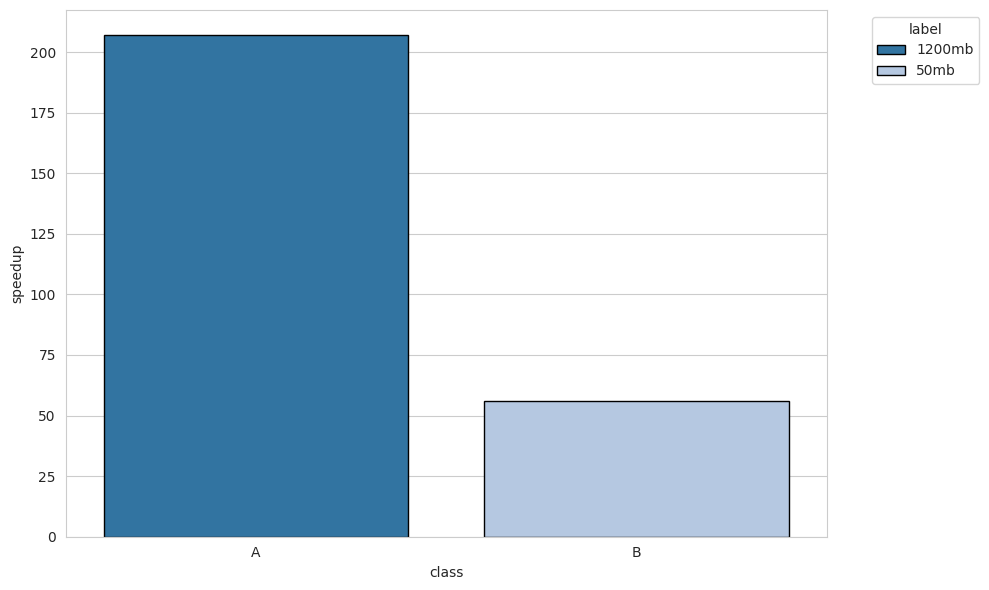

In [55]:
data = pd.DataFrame({
    'class': ['A', 'B'],
    'speedup': [207, 56],
    'label': ['1200mb', '50mb']
})

# 设置风格
sns.set_style("whitegrid")

# 创建画布
plt.figure(figsize=(10, 6))

# 绘制分组柱状图，使用深蓝和浅蓝配色
sns.barplot(
    data=data,
    x='class',
    y='speedup',
    hue='label',  # 按分组区分颜色
    palette=['#1f77b4', '#aec7e8'],  # 深蓝和浅蓝的十六进制颜色码
    edgecolor='black'
)

plt.legend(title='label', bbox_to_anchor=(1.05, 1), loc='upper left')

# 显示
plt.tight_layout()
plt.show()

In [1]:
total_size = sys.getsizeof(X)  

print(f"列表总内存大小: {total_size/1024**2} mb")

NameError: name 'sys' is not defined